In [1]:
#!pip install yfinance

In [2]:
#!pip install xgboost

In [3]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = yf.download(
    "AAPL",
    start="2015-01-01",
    end="2025-01-01",
    auto_adjust=False
)

print(df.head())                       # Display first 5 records
print(df.columns)                      # Display column names

C:\ProgramData\anaconda3\lib\site-packages\yfinance\scrapers\history.py:396: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
[*********************100%***********************]  1 of 1 completed

Price       Adj Close      Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                                        
2015-01-02  24.192602  27.332500  27.860001  26.837500  27.847500  212818400
2015-01-05  23.511061  26.562500  27.162500  26.352501  27.072500  257142000
2015-01-06  23.513277  26.565001  26.857500  26.157499  26.635000  263188400
2015-01-07  23.842985  26.937500  27.049999  26.674999  26.799999  160423600
2015-01-08  24.759081  27.972500  28.037500  27.174999  27.307501  237458000
MultiIndex([('Adj Close', 'AAPL'),
            (    'Close', 'AAPL'),
            (     'High', 'AAPL'),
            (      'Low', 'AAPL'),
            (     'Open', 'AAPL'),
            (   'Volume', 'AAPL')],
           names=['Price', 'Ticker'])


Data Cleaning

In [5]:
df = df.reset_index()

In [6]:
print(df.head())             # Display first 5 records
print(df.columns)            # Display column names  

Price        Date  Adj Close      Close       High        Low       Open  \
Ticker                  AAPL       AAPL       AAPL       AAPL       AAPL   
0      2015-01-02  24.192602  27.332500  27.860001  26.837500  27.847500   
1      2015-01-05  23.511061  26.562500  27.162500  26.352501  27.072500   
2      2015-01-06  23.513277  26.565001  26.857500  26.157499  26.635000   
3      2015-01-07  23.842985  26.937500  27.049999  26.674999  26.799999   
4      2015-01-08  24.759081  27.972500  28.037500  27.174999  27.307501   

Price      Volume  
Ticker       AAPL  
0       212818400  
1       257142000  
2       263188400  
3       160423600  
4       237458000  
MultiIndex([(     'Date',     ''),
            ('Adj Close', 'AAPL'),
            (    'Close', 'AAPL'),
            (     'High', 'AAPL'),
            (      'Low', 'AAPL'),
            (     'Open', 'AAPL'),
            (   'Volume', 'AAPL')],
           names=['Price', 'Ticker'])


In [7]:
# Flatten MultiIndex columns
df.columns = ['Date', 'Adj_Close', 'Close', 'High', 'Low', 'Open', 'Volume']

print(df.head())
print(df.columns)

        Date  Adj_Close      Close       High        Low       Open     Volume
0 2015-01-02  24.192602  27.332500  27.860001  26.837500  27.847500  212818400
1 2015-01-05  23.511061  26.562500  27.162500  26.352501  27.072500  257142000
2 2015-01-06  23.513277  26.565001  26.857500  26.157499  26.635000  263188400
3 2015-01-07  23.842985  26.937500  27.049999  26.674999  26.799999  160423600
4 2015-01-08  24.759081  27.972500  28.037500  27.174999  27.307501  237458000
Index(['Date', 'Adj_Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2516 entries, 0 to 2515
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2516 non-null   datetime64[ns]
 1   Adj_Close  2516 non-null   float64       
 2   Close      2516 non-null   float64       
 3   High       2516 non-null   float64       
 4   Low        2516 non-null   float64       
 5   Open       2516 non-null   float64       
 6   Volume     2516 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 137.7 KB


In [9]:
df['Date'] = pd.to_datetime(df['Date'])

Converting Date to Datetime to ensure time based calculations and analysis can be performed.

Exploratory Data Analysis

In [10]:
df.isnull().sum()

Date         0
Adj_Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

No missing values are found in the dataset.

Creating Individual Plots to visualize column relationships 

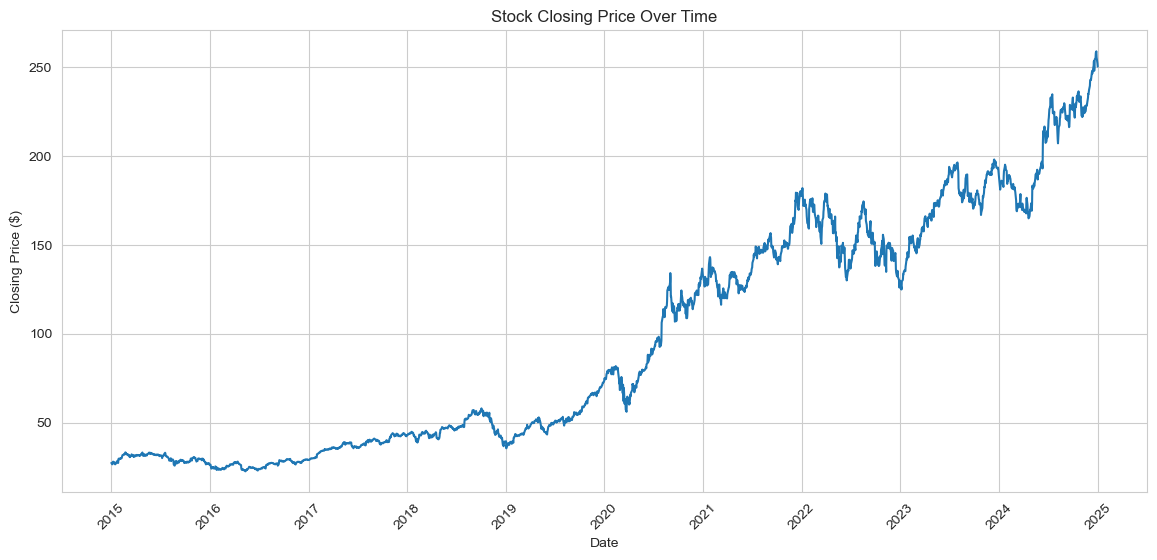

In [11]:
sns.set_style("whitegrid")

plt.figure(figsize=(14,6))
sns.lineplot(data=df, x='Date', y='Close')
plt.title('Stock Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')
plt.xticks(rotation=45)
plt.show()

Significant fluctuations are visible, particularly around 2020–2023, indicating periods of increased market volatility.
As time progresses short-term declines increase but the stock demonstrates sustained long term growth over the entire period.
The stock exhibits an overall bullish trend, suggesting that historical prices contain meaningful patterns that can be leveraged for predictive modeling.

In [12]:
df.describe()

,Adj_Close,Close,High,Low,Open,Volume
count,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000,2.516000e+03
mean,93.684878,96.363971,97.299699,95.323938,96.275646,1.170853e+08
std,65.319931,65.255230,65.849313,64.567788,65.174986,6.839614e+07
min,20.565865,22.584999,22.917500,22.367500,22.500000,2.323470e+07
25%,35.157636,37.639375,38.040001,37.295626,37.606874,7.105610e+07
50%,64.268620,66.661251,67.281250,65.807503,66.549999,1.003646e+08
75%,149.955418,152.772503,154.564999,150.812504,152.572506,1.426216e+08
max,257.375610,259.019989,260.100006,257.630005,258.190002,6.488252e+08


The summary statistics indicate that the stock prices exhibit substantial variation over the study period, as reflected by the standard deviations of the Open, High, Low, and Close prices. The mean and median values are relatively close, suggesting a fairly symmetric distribution of stock prices. Trading volume shows higher variability and positive skewness, indicating occasional periods of unusually high market activity. The presence of kurtosis greater than zero would suggest the occurrence of extreme values and higher-than-normal volatility in trading behavior.

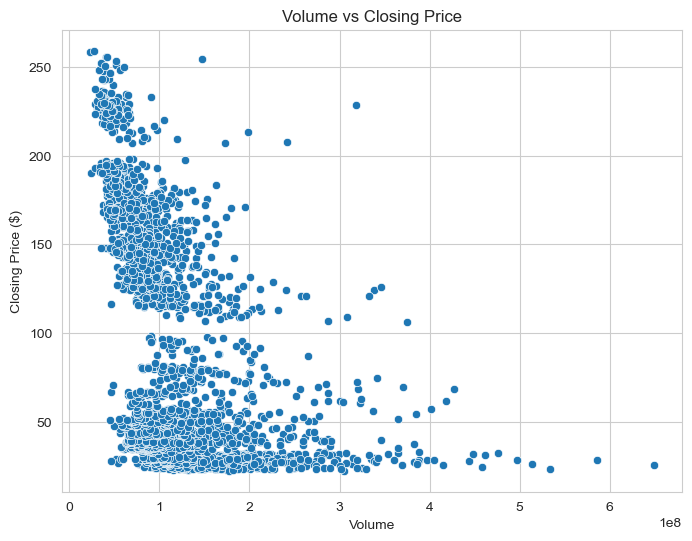

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Volume', y='Close')
plt.title('Volume vs Closing Price')
plt.xlabel('Volume')
plt.ylabel('Closing Price ($)')
plt.show()

Higher trading volumes are observed at lower stock prices while higher stock prices are observed at moderate trading volumes. The data points are widely scattered indicating substantial variability. This dispersed pattern and moderate negative correlation observed in the dataset suggests volume alone is not a strong predictor of closing price.

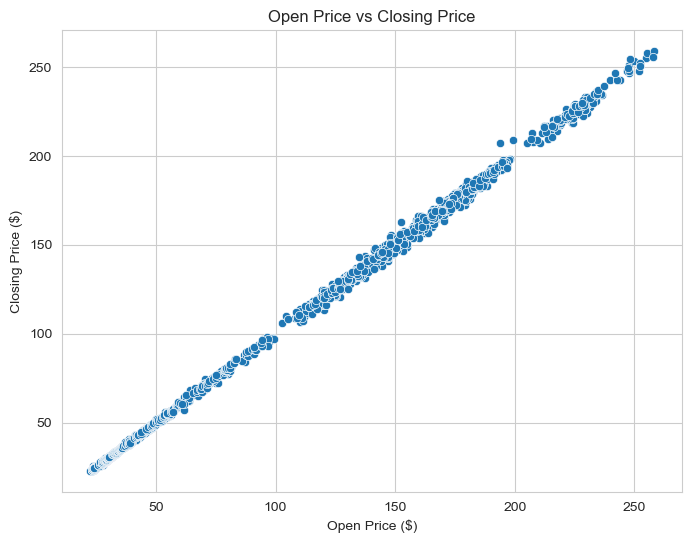

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Open', y='Close')
plt.title('Open Price vs Closing Price')
plt.xlabel('Open Price ($)')
plt.ylabel('Closing Price ($)')
plt.show()

A nearly perfect positive linear relationship exists between opening and closing prices. Data points are concentrated closely around a straight line with minimal dispersion. As opening price increases, closing price increases proportionally making opening price a strong predictor of closing price and is highly suitable for inclusion in the regression model.

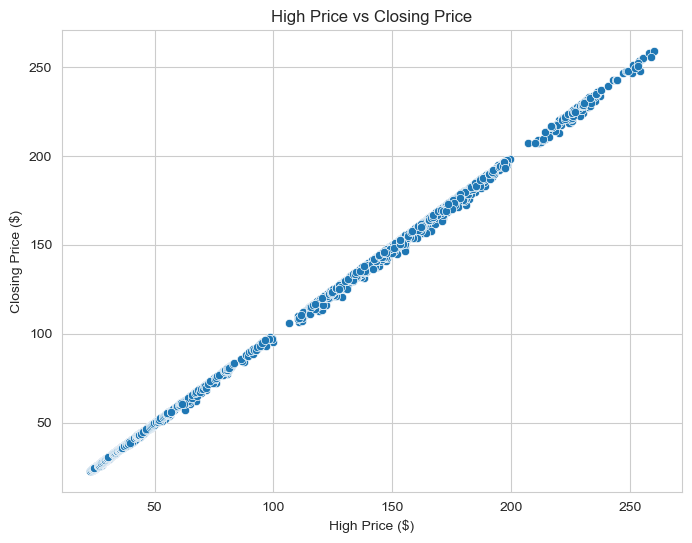

In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='High', y='Close')
plt.title('High Price vs Closing Price')
plt.xlabel('High Price ($)')
plt.ylabel('Closing Price ($)')
plt.show()

High price has extremely strong predictive power for closing price and represents one of the most influential features in the model as the scatter plot forms a narrow diagonal pattern with very little variation.

Creating sub plots for side by side comparison of column relationships

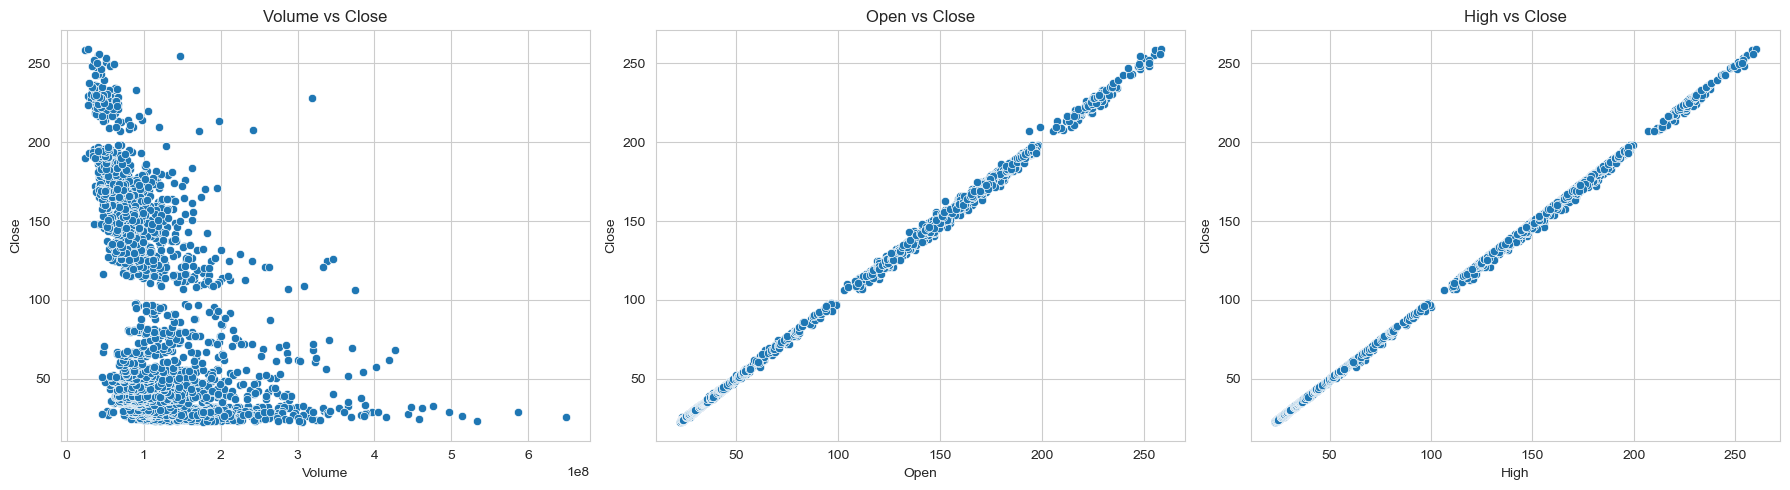

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x='Volume', y='Close', ax=axes[0])
axes[0].set_title('Volume vs Close')

sns.scatterplot(data=df, x='Open', y='Close', ax=axes[1])
axes[1].set_title('Open vs Close')

sns.scatterplot(data=df, x='High', y='Close', ax=axes[2])
axes[2].set_title('High vs Close')

plt.tight_layout()
plt.show()

Visual inspection confirms that Open and High prices are significantly more informative predictors than Volume, supporting their selection for model development.

Feature Engineering

In [17]:
# Create lag feature
df['Prev_Close'] = df['Close'].shift(1)

# Moving averages
df['MA_5'] = df['Close'].rolling(5).mean()
df['MA_20'] = df['Close'].rolling(20).mean()

# Daily return
df['Daily_Return'] = df['Close'].pct_change()

# Target = next day's close price
df['Target'] = df['Close'].shift(-1)

# Remove NaNs created by rolling and shifting
df = df.dropna()

In [18]:
df.shape

(2496, 12)

Rows with missing values generated by lag and moving average calculations were removed. The final dataset contains 2496 records and 12 features.

In [19]:
df.head()      # Display first 5 records

,Date,Adj_Close,Close,High,Low,Open,Volume,Prev_Close,MA_5,MA_20,Daily_Return,Target
19,2015-01-30,25.925238,29.290001,30.000000,29.212500,29.600000,334982000,29.725000,28.6805,27.660375,-0.014634,29.657499
20,2015-02-02,26.250511,29.657499,29.792500,29.020000,29.512501,250956400,29.290001,28.9570,27.776625,0.012547,29.662500
21,2015-02-03,26.254942,29.662500,29.772499,29.402500,29.625000,207662800,29.657499,29.4325,27.931625,0.000169,29.889999
22,2015-02-04,26.456308,29.889999,30.127501,29.577499,29.625000,280598800,29.662500,29.6450,28.097875,0.007670,29.985001
23,2015-02-05,26.645134,29.985001,30.057501,29.812500,30.004999,168984800,29.889999,29.6970,28.250250,0.003178,29.732500


The current dataset captures information from the previous trading day and helps model short term price continuity and momentum.

Displaying Correlation between features

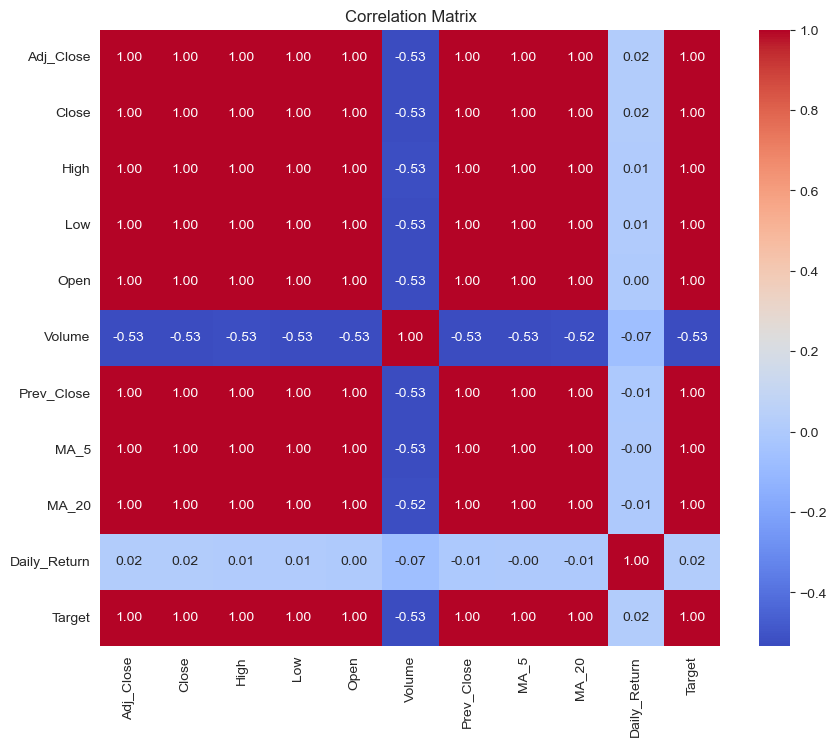

In [20]:
# Correlation matrix
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Matrix')
plt.show()

Open, High, Low, Previous Close, MA_5, and MA_20 exhibit extremely high positive correlations with the target variable. Volume shows a moderate negative correlation with stock prices. Daily Return has very weak correlation with the target variable. Hence,
strong correlations between price related features and the target indicate substantial predictive potential, while Volume and Daily Return contribute relatively less explanatory power.

In [21]:
# Based on observation from correlation matrix 'Daily_Return' is being dropped
features = [
    'Open',
    'High',
    'Low',
    'Prev_Close',
    'MA_5',
    'MA_20',
    'Volume' # Due to moderate correlation with target, it is decided to keep 'Volume' in training data
]

target = 'Target'

Feature selection was guided by both correlation analysis and visual inspection. Open, High, Low, Previous Close, MA_5, and MA_20 exhibited very strong positive correlations with the target variable and showed clear linear relationships in scatter plots. Volume was retained despite its weaker correlation because trading activity may still provide additional market information. Daily Return was excluded due to its negligible correlation with the target variable and limited predictive contribution.

Data Preprocessing and Model Building

In [22]:
X = df[features]                             # Storing independent variables in X
y = df['Target']                             # Storing Target variable in y

In [23]:
# Performing 80-20% train test split without randomness because of time series data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Displaying shape of the train and test data
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1996, 7)
Testing set: (500, 7)


In [24]:
# Scaling the data with Standard Scaler for Regression prediction
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:5])

[[-0.89544114 -0.89256398 -0.89860376 -0.89247895 -0.91331526 -0.9284832
   3.07848227]
 [-0.8972277  -0.89674506 -0.90258732 -0.90135799 -0.90766799 -0.92610252
   1.81304689]
 [-0.8949307  -0.89714806 -0.89467191 -0.89385676 -0.89795631 -0.92292828
   1.16104021]
 [-0.8949307  -0.88999487 -0.8910505  -0.89375468 -0.89361619 -0.91952366
   2.25946491]
 [-0.8871719  -0.89140535 -0.88618743 -0.88911106 -0.89255413 -0.91640318
   0.578545  ]]


Standardized features to improve model stability and ensuring all variables are on the same scale.

In [25]:
# Verifying scaled data
scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

scaled_df.describe().round(2) # rounding of values for a cleaner visual representation

,Open,High,Low,Prev_Close,MA_5,MA_20,Volume
count,1996.00,1996.00,1996.00,1996.00,1996.00,1996.00,1996.00
mean,0.00,0.00,0.00,0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.04,-1.04,-1.04,-1.04,-1.03,-1.01,-1.44
25%,-0.83,-0.83,-0.83,-0.83,-0.83,-0.84,-0.67
50%,-0.51,-0.51,-0.51,-0.51,-0.51,-0.51,-0.28
75%,1.04,1.03,1.03,1.04,1.03,1.02,0.36
max,2.23,2.19,2.20,2.22,2.16,2.12,7.80


The selected predictor variables were standardized using StandardScaler. After scaling, all features have approximately zero mean and unit variance, ensuring that variables measured on different scales contribute equally during model training. The summary statistics of the scaled training data confirm successful standardization, with means close to zero and standard deviations close to one for all predictor variables.

In [26]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train) # Fitting the model on train data

y_pred = lr.predict(X_test_scaled) # Finding predicted values from test data

Model Evaluation

In [27]:
mae = mean_absolute_error(y_test, y_pred) # calculating MAE with respect to test data and predicted values
mse = mean_squared_error(y_test, y_pred)  # calculating MSE with respect to test data and predicted values
rmse = np.sqrt(mse)                       # calculating RMSE
r2 = r2_score(y_test, y_pred)             # calculating R² score with respect to test data and predicted values

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 2.059554714774203
MSE : 7.5436039920614
RMSE: 2.7465622133972136
R²  : 0.9900871971209521


Approximately 99.01% of the variation in next-day stock prices is explained by the selected predictor variables. Since RMSE penalizes larger errors more heavily than MAE, the fact that RMSE is only slightly larger than MAE suggests there are few extreme prediction errors.

Visualizing Model Performance

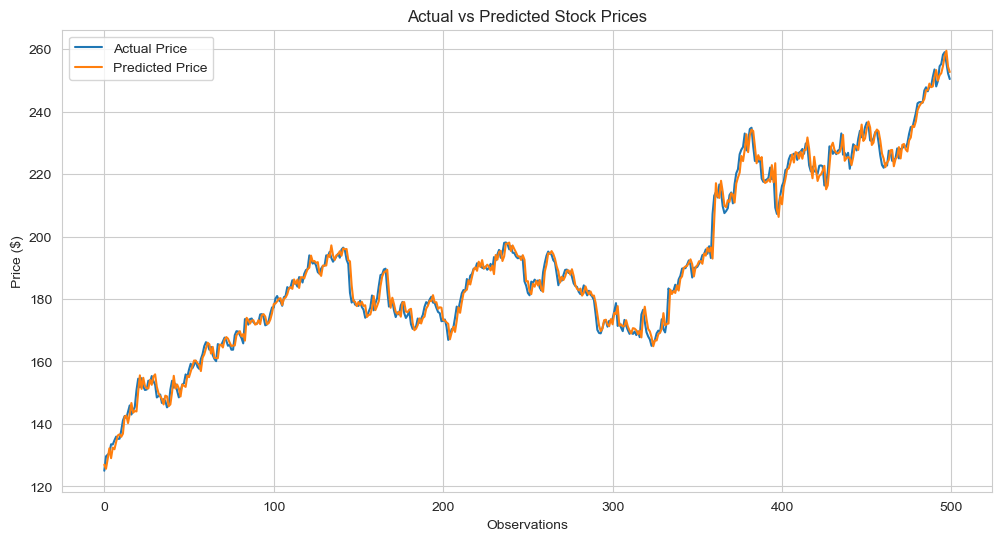

In [28]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')

plt.title('Actual vs Predicted Stock Prices')
plt.xlabel('Observations')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

A Linear Regression model was trained using Open Price, High Price, Low Price, Previous Closing Price, Moving Averages (MA_5 and MA_20), and Trading Volume as predictor variables. Model evaluation demonstrated excellent predictive performance, achieving an R squared score of around 0.9901, indicating that approximately 99% of the variation in stock prices was explained by the model. The MAE of 2.06 and RMSE of 2.75 suggest that prediction errors were relatively small compared to the overall stock price range. Furthermore, the Actual vs Predicted visualization showed a strong overlap between predicted and observed values, confirming the model's ability to capture both short-term fluctuations and long-term market trends.

Attempting to Improve Prediction

In [29]:
# Testing if Random Forest Regressor improves prediction
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

rf_pred = rf.predict(X_test_scaled)

In [30]:
rf_mae = mean_absolute_error(y_test, rf_pred)  # calculating MAE with respect to test data and predicted values
rf_mse = mean_squared_error(y_test, rf_pred)   # calculating MSE with respect to test data and predicted values
rf_rmse = np.sqrt(rf_mse)                      # calculating RMSE
rf_r2 = r2_score(y_test, rf_pred)              # calculating R² score with respect to test data and predicted values

print("Random Forest Results")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Results
MAE : 18.77385446380615
MSE : 811.4940728234398
RMSE: 28.486735032703198
R²  : -0.06635777671785403


An R squared score below 0 means the Random Forest not just performed worse but failed to make an expected prediction of the stock price.

Comparing with Linear Regression

In [31]:
comparison = pd.DataFrame({                              # Comparing evaluation metrics of Linear Regression with that of Random Forest
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, rf_mae],
    'RMSE': [rmse, rf_rmse],
    'R²': [r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R²
0,Linear Regression,2.059555,2.746562,0.990087
1,Random Forest,18.773854,28.486735,-0.066358


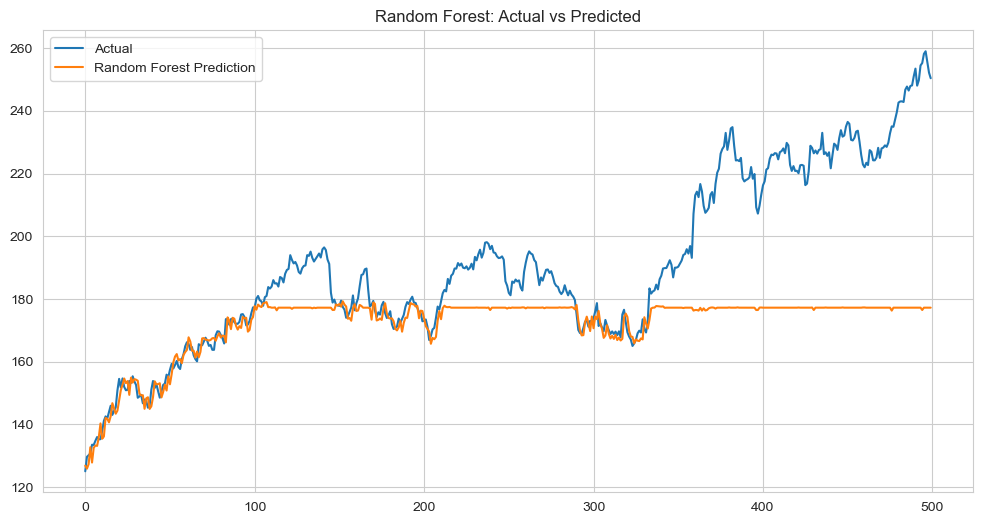

In [32]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual')
plt.plot(rf_pred, label='Random Forest Prediction')

plt.title('Random Forest: Actual vs Predicted')
plt.legend()
plt.show()

Random Forest Regressor was evaluated as an alternative to Linear Regression. However, its performance was substantially worse, achieving an R squared score of -0.066 compared to 0.990 for Linear Regression. Visualization of the predictions revealed that the Random Forest produced nearly constant predictions during periods where stock prices exceeded the range observed in the training data. This occurs because Random Forest models are unable to extrapolate beyond previously observed values. In contrast, Linear Regression successfully captured the underlying upward trend in stock prices, resulting in significantly lower prediction errors and superior predictive performance. Therefore, to improve prediction we need to use models that can better find trend equation and make better handle multicollinearity among columns.

Hyperparameter Tuning with GridSearchCV using Linear Regression, Ridge, Random Forest and XGBoost Regressors

In [33]:
tscv = TimeSeriesSplit(n_splits=5) # Using a time aware cross validation to preserve chronological order and prevent data leakage

lr_params = {                                      # Defining parameter range of Linear Regression for GridSearchCV
    'fit_intercept': [True, False],
    'positive': [False, True]
}

lr_grid = GridSearchCV(
    LinearRegression(),
    lr_params,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)

lr_grid.fit(X_train_scaled, y_train)              # Applying GridSearchCV on Linear Regression

best_lr = lr_grid.best_estimator_

ridge_params = {                                  # Defining parameter range of Ridge Regression for GridSearchCV
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)

ridge_grid.fit(X_train_scaled, y_train)           # Applying GridSearchCV on Ridge Regression

best_ridge = ridge_grid.best_estimator_

rf_params = {                                     # Defining parameter range of Random Forest for GridSearchCV
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)              # Applying GridSearchCV on Random Forest

best_rf = rf_grid.best_estimator_

xgb_params = {                                    # Defining parameter range of XGBoost Regressor for GridSearchCV
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBRegressor(
        objective='reg:squarederror',
        random_state=42
    ),
    xgb_params,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)

xgb_grid.fit(X_train_scaled, y_train)             # Applying GridSearchCV on XGBoost Regressor

best_xgb = xgb_grid.best_estimator_


# Displaying the best selected parameters for each of the models
print("Best Linear Regression:", lr_grid.best_params_)
print("Best Ridge:", ridge_grid.best_params_)
print("Best Random Forest:", rf_grid.best_params_)
print("Best XGBoost:", xgb_grid.best_params_)

Best Linear Regression: {'fit_intercept': True, 'positive': False}
Best Ridge: {'alpha': 0.001}
Best Random Forest: {'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best XGBoost: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 300, 'subsample': 0.8}


In [34]:
models = {                                               # Creating a dictionary of best estimators of each model
    'Linear Regression': best_lr,
    'Ridge Regression': best_ridge,
    'Random Forest': best_rf,
    'XGBoost': best_xgb
}

results = []                                             # Creating a list to store results

for name, model in models.items():                       # Applying a loop to get the results of the specific model

    pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append({                                     # Appending the results respectively in a DataFrame for better analysis
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='R²',
    ascending=False
)

# Displaying the newly created DataFrame for model evaluation
print(results_df)

               Model        MAE       RMSE        R²
1   Ridge Regression   2.059327   2.746162  0.990090
0  Linear Regression   2.059555   2.746562  0.990087
2      Random Forest  18.326919  28.041868 -0.033312
3            XGBoost  19.231493  28.983853 -0.103900


Four regression models were evaluated using hyperparameter tuning and time series cross validation: Linear Regression, Ridge Regression, Random Forest Regressor and XGBoost Regressor. Ridge Regression achieved the best predictive performance with an R² score of 0.9901, MAE of 2.06, and RMSE of 2.75. The strong performance of Ridge Regression is attributed to its ability to handle multicollinearity among highly correlated stock price features through L2 regularization. In contrast, Random Forest and XGBoost exhibited poor generalization performance, producing negative R² scores on the test set.

Visualization of model comparison

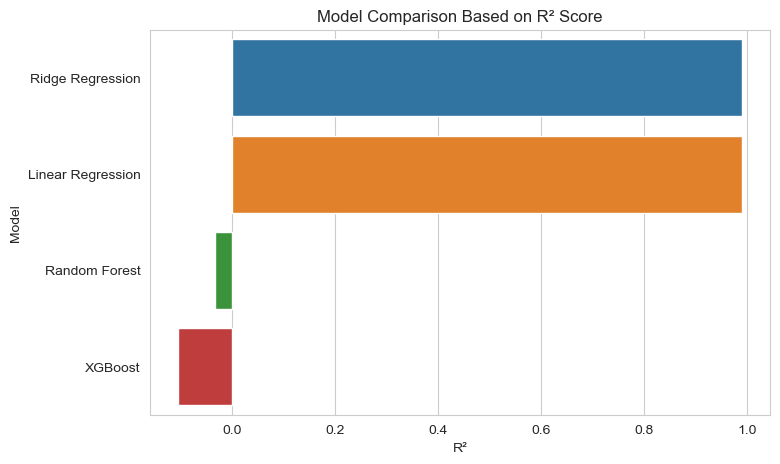

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x='R²',
    y='Model'
)

plt.title('Model Comparison Based on R² Score')
plt.show()

Ridge Regression achieved the highest R² score (≈0.9901), making it the best-performing model for predicting next-day stock prices. Linear Regression produced nearly identical results, while Random Forest and XGBoost performed poorly with negative R² scores. These findings indicate that the relationships between the selected features and future stock prices are primarily linear, making Ridge Regression the most suitable model for this dataset.

## Summary and Conclusion

### Project Overview

The objective of this project was to develop and evaluate machine learning models capable of predicting Apple's next-day stock closing price using historical stock market data obtained from Yahoo Finance. The dataset contained daily stock information from 2015 to 2025, including Open, High, Low, Close, Adjusted Close prices, and Trading Volume. The project followed a complete machine learning workflow consisting of data collection, data cleaning, exploratory data analysis (EDA), feature engineering, feature selection, preprocessing, model development, hyperparameter tuning, and performance evaluation.

---

### Exploratory Data Analysis

The exploratory analysis provided valuable insights into the behavior of Apple's stock prices over the ten-year period. The stock closing price trend showed a strong long-term upward movement, indicating sustained growth despite periods of short-term volatility and market fluctuations. This suggested that historical price patterns contain meaningful information that could be utilized for predictive modeling.

Summary statistics revealed substantial variation in stock prices throughout the observation period. The mean and median values of the price-related variables were relatively close, suggesting a reasonably balanced distribution of prices. Trading Volume exhibited considerably greater variability, indicating periods of unusually high market activity.

Scatter plot analysis demonstrated strong positive linear relationships between Open Price, High Price, and Closing Price. In contrast, Trading Volume showed a weaker and more dispersed relationship with the target variable. These visual findings suggested that price-based variables would likely be more effective predictors of future stock prices than trading volume alone.

Correlation analysis further confirmed these observations. Open, High, Low, Previous Close, MA_5, and MA_20 exhibited extremely strong positive correlations with the target variable, while Daily Return showed a negligible relationship. These findings provided quantitative evidence supporting the selection of price-based features for model development.

---

### Feature Engineering and Feature Selection

Several additional features were created to capture temporal dependencies and market trends that may influence future stock prices.

* **Previous Close (Prev_Close):** Created to capture short-term momentum and the dependence of future prices on recent market behavior.
* **5-Day Moving Average (MA_5):** Introduced to represent short-term trends while reducing daily price fluctuations.
* **20-Day Moving Average (MA_20):** Added to capture medium-term market trends and smooth market noise.
* **Daily Return:** Calculated to measure percentage price changes between consecutive trading days.

Feature selection was based on a combination of correlation analysis and visual inspection. Daily Return was excluded because of its negligible correlation with the target variable, indicating limited predictive usefulness in a regression framework. The final feature set consisted of Open Price, High Price, Low Price, Previous Close, MA_5, MA_20, and Trading Volume.

This selection process ensured that the model utilized variables with strong predictive relationships while avoiding unnecessary complexity.

---

### Data Preprocessing

Since stock market data is inherently time-dependent, a chronological train-test split was performed using an 80:20 ratio without random shuffling. This approach preserved the temporal sequence of observations and prevented information from future periods leaking into the training data.

Feature scaling was performed using StandardScaler. Standardization transformed all predictor variables to a common scale with approximately zero mean and unit variance. This step was particularly important because Ridge Regression applies regularization penalties that are sensitive to differences in feature magnitude. Scaling therefore improved model stability and ensured fair treatment of all predictor variables during training.

---

### Model Development and Evaluation

Multiple machine learning models were developed and evaluated to determine the most suitable approach for stock price prediction.

##### Linear Regression

Linear Regression served as the baseline model due to the strong linear relationships identified during exploratory analysis. The model achieved excellent predictive performance, demonstrating that a significant portion of stock price variation could be explained using the selected predictor variables.

##### Random Forest Regressor

Random Forest Regressor was evaluated as a non-linear alternative. However, the model performed substantially worse than Linear Regression, producing a negative R² score. Analysis of the predictions revealed that the model struggled to extrapolate stock prices beyond the range observed during training. As a result, predictions became nearly constant during periods when stock prices continued to rise.

##### XGBoost Regressor

XGBoost Regressor was also evaluated due to its strong reputation for predictive performance. Despite hyperparameter tuning, the model produced results similar to Random Forest and failed to generalize effectively to unseen future data. This outcome suggests that the stock price relationships present in the dataset were primarily linear and therefore better captured by linear models than tree-based ensemble methods.

##### Ridge Regression

Ridge Regression achieved the best overall performance among all evaluated models. By incorporating L2 regularization, Ridge Regression effectively addressed the multicollinearity present among highly correlated price-based features while maintaining excellent predictive accuracy.

---

### Hyperparameter Tuning

To ensure fair comparison and optimal performance, hyperparameter tuning was performed using GridSearchCV combined with TimeSeriesSplit cross-validation. TimeSeriesSplit was selected because it preserves chronological order and is more appropriate for financial time-series data than traditional random cross-validation techniques.

The tuning process identified the best-performing configuration for each model and enabled objective comparison based on predictive performance rather than default parameter settings.

---

### Final Model Performance

Among all evaluated models, Ridge Regression achieved the strongest results:

* **R² Score:** 0.9901
* **MAE:** Approximately 2.06
* **RMSE:** Approximately 2.75

These results indicate that the model successfully explained approximately 99% of the variation in next-day stock prices. Furthermore, the relatively low MAE and RMSE values suggest that prediction errors remained small when compared to the overall stock price range.

The Actual vs Predicted visualization showed a very strong overlap between observed and predicted values, providing further evidence of the model's effectiveness in capturing both long-term trends and short-term price movements.

---

### Most Influential Features

Based on correlation analysis, visual inspection, and model performance, the most influential predictors of stock prices were:

1. Open Price
2. High Price
3. Low Price
4. Previous Close Price
5. 5-Day Moving Average (MA_5)
6. 20-Day Moving Average (MA_20)

These features demonstrated extremely strong positive relationships with future stock prices and contributed significantly to the model's predictive capability. Trading Volume provided supplementary information but was considerably less influential than the price-based indicators.

---

### Limitations and Future Improvements

Although the Ridge Regression model achieved excellent predictive performance, several opportunities exist for further improvement.

Future work could include:

* Incorporating additional technical indicators such as RSI, MACD and Exponential Moving Averages.
* Including external market variables such as NASDAQ indices, S&P 500 performance, interest rates, inflation data and economic indicators.
* Integrating news sentiment analysis and company-specific financial information.
* Creating additional lag features using multiple previous trading days.
* Applying advanced time series forecasting techniques such as ARIMA, Prophet, LSTM or GRU neural networks.
* Using walk-forward validation to simulate real-world forecasting scenarios more accurately.

These enhancements may provide additional predictive information and further improve forecasting accuracy.

---

### Final Conclusion

This project successfully demonstrated the application of machine learning techniques for stock price prediction using historical Apple stock data. Through comprehensive exploratory analysis, feature engineering, preprocessing, model comparison, and hyperparameter tuning, Ridge Regression emerged as the most effective model. The model achieved exceptional predictive performance, explaining approximately 99% of the variation in stock prices while maintaining low prediction error. The results indicate that recent price behavior and moving-average trends are the strongest determinants of future stock prices within this dataset. Overall, the project highlights the effectiveness of regularized linear models for financial forecasting when strong linear relationships exist among predictor variables and the target variable.
